In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [59]:
df=pd.read_csv("flats_outlier_treatment.csv")

In [60]:
df.shape

(3034, 27)

In [61]:
df.head()

,Unnamed: 0,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,0,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,1.0,13939.950980,1,1,1,1,1,1,1,0,0,0,135.0,37,3,New Property
1,1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,NaN,13560.752170,1,1,0,0,1,1,0,0,0,1,150.0,31,3,New Property
2,2,Askari,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,NaN,3.55,10.0,2720.0,1.0,1.0,1.0,13051.470588,1,1,1,1,1,1,1,1,1,1,156.0,49,NaN,New Property
3,3,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,NaN,4.45,7.6,2067.2,1.0,2.0,1.0,21526.702786,1,1,0,0,1,0,0,0,0,1,125.0,18,NaN,New Property
4,4,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,1.0,14012.777242,1,1,0,0,1,1,0,0,0,1,100.0,18,3,New Property


In [62]:
df.isnull().sum()

Unnamed: 0                   0
society                      0
bedrooms                    94
baths                       30
link                         0
floors_in_building        1409
price                        0
area                         0
area_sqft                    0
servant_quarters          1354
kitchens                   738
store_rooms               1322
price_per_sqft               0
drawing_room                 0
dining_room                  0
lounge_or_sitting_room       0
laundry_room                 0
study_room                   0
prayer_room                  0
powder_room                  0
gym                          0
steam_room                   0
other_rooms                  0
luxury_score                 0
furnishing_score             0
floor                     1108
agePossession                0
dtype: int64

In [63]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")


In [64]:
df[df['bedrooms'].isnull()].iloc[1]['link']

'https://www.zameen.com/Property/bahria_town_sector_f_bahria_town_-_tauheed_block_studio_apartment_320_sq_ft_bahria_town_lahore-53887512-11864-1.html'

In [65]:
text = df["link"].fillna("").str.lower()
missing = df["bedrooms"].isna()

is_studio = text.str.contains(r"\bstudio\b|studio_apartment|studio-apartment", regex=True)
is_1bed = text.str.contains(r"\b1[-_\s]?(?:bed|bedroom|beds)\b", regex=True)

df.loc[missing & is_studio, "bedrooms"] = 0
df.loc[missing & is_1bed, "bedrooms"] = 1

In [66]:
is_studio.sum()

np.int64(122)

In [67]:
df[df['bedrooms'].isnull()]['link'].value_counts()

link
https://www.zameen.com/Property/bahria_town_bahria_town_-_sector_e_studio_ready_to_move_apartment_available_for_sale_in_sector_e_bahria_town_lahore-53931097-1802-1.html                                                                                                      1
https://www.zameen.com/Property/bahria_town_bahria_town_-_sector_b_prime_location_apartment_available_for_sale_in_bahria_town_lahore-53781563-1772-1.html                                                                                                                     1
https://www.zameen.com/Property/bahria_town_bahria_town_-_sector_c_4_star_serviced_apartment_managed_by_falettis_hotels_bahria_town-53909154-1784-1.html                                                                                                                      1
https://www.zameen.com/Property/bahria_town_bahria_town_-_sector_b_prime_location_apartments_in_madina_heights_5_bahria_town_lahore_available_on_easy_installments-53781570-1772-1.

In [68]:
import re
import numpy as np

def bedrooms_from_link(s):
    if pd.isna(s):
        return np.nan
    s = s.lower()
    if "studio" in s:
        return 0
    # skip ranges like 1_2_bed
    if re.search(r"\b\d+[_-]\d+\s*bed", s):
        return np.nan
    m = re.search(r"\b(\d+)\s*[-_ ]?(?:bed|bedroom|beds)\b", s)
    return int(m.group(1)) if m else np.nan

missing = df["bedrooms"].isna()
df.loc[missing, "bedrooms"] = df.loc[missing, "link"].apply(bedrooms_from_link)

df["bedrooms"].isna().sum()


np.int64(52)

In [69]:
df["bedrooms"].isna().sum()

np.int64(52)

In [70]:
df.shape

(3034, 26)

In [77]:
df[df['bedrooms'].isnull()]['link'].value_counts()

link
https://www.zameen.com/Property/bahria_town_bahria_town_-_sector_b_prime_location_apartment_available_for_sale_in_bahria_town_lahore-53781563-1772-1.html                         1
https://www.zameen.com/Property/bahria_town_sector_e_bahria_town_-_nishtar_block_food_court_bahria_town_lahore-53760506-1806-1.html                                               1
https://www.zameen.com/Property/main_boulevard_gulberg_cbd_punjab_pcbdda_1-bed_furnished_apartment_for_sale_cbd_lahore-52901360-21580-1.html                                      1
https://www.zameen.com/Property/main_boulevard_gulberg_cbd_punjab_pcbdda_1-bed_furnished_apartment_for_sale_cbd_lahore-53238662-21580-1.html                                      1
https://www.zameen.com/Property/al_kabir_town_al-kabir_town_-_phase_2_476_square_feet_flat_in_al-kabir_town_-_phase_2_best_option-53583277-11704-1.html                           1
https://www.zameen.com/Property/lahore_main_canal_bank_road_865_square_feet_modern_2_bed_apartm

In [72]:
df["bedrooms"] = df["bedrooms"].fillna(df["baths"])


In [ ]:
df.isn

,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,1.0,13939.950980,1,1,1,1,1,1,1,0,0,0,135.0,37,3,New Property
1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,NaN,13560.752170,1,1,0,0,1,1,0,0,0,1,150.0,31,3,New Property
2,Askari,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,NaN,3.55,10.0,2720.0,1.0,1.0,1.0,13051.470588,1,1,1,1,1,1,1,1,1,1,156.0,49,NaN,New Property
3,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,NaN,4.45,7.6,2067.2,1.0,2.0,1.0,21526.702786,1,1,0,0,1,0,0,0,0,1,125.0,18,NaN,New Property
4,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,1.0,14012.777242,1,1,0,0,1,1,0,0,0,1,100.0,18,3,New Property
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029,New Samanabad,2.0,1.0,https://www.zameen.com/Property/lahore_new_sam...,10.0,0.40,2.0,544.0,NaN,NaN,NaN,7352.941176,0,1,0,0,0,0,0,0,0,1,132.0,31,3,New Property
3030,Multan Road,2.0,2.0,https://www.zameen.com/Property/multan_road_ya...,NaN,0.45,2.5,680.0,NaN,NaN,NaN,6617.647059,0,0,0,0,0,0,0,0,0,0,2.0,0,NaN,Undefined
3031,Cantt,3.0,4.0,https://www.zameen.com/Property/aziz_bhatti_ro...,5.0,4.30,11.6,3155.2,NaN,NaN,NaN,13628.296146,1,1,1,1,1,1,1,1,1,1,177.0,49,8,Relatively New
3032,Revenue Society,2.0,2.0,https://www.zameen.com/Property/revenue_societ...,5.0,1.05,2.9,788.8,NaN,NaN,NaN,13311.359026,1,1,1,1,0,1,1,1,1,1,151.0,39,3,Relatively New


In [78]:
df['bedrooms'].describe()

count    3023.000000
mean        2.092292
std         1.072064
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: bedrooms, dtype: float64

In [85]:
mean_bed = df["bedrooms"].mean()
df["bedrooms"] = df["bedrooms"].fillna(mean_bed)


In [86]:
df.isnull().sum()

society                      0
bedrooms                     0
baths                       29
link                         0
floors_in_building        1409
price                        0
area                         0
area_sqft                    0
servant_quarters          1354
kitchens                   738
store_rooms               1322
price_per_sqft               0
drawing_room                 0
dining_room                  0
lounge_or_sitting_room       0
laundry_room                 0
study_room                   0
prayer_room                  0
powder_room                  0
gym                          0
steam_room                   0
other_rooms                  0
luxury_score                 0
furnishing_score             0
floor                     1108
agePossession                0
dtype: int64

In [ ]:
df['baths'].describe()

count    3005.000000
mean        2.303827
std         1.344913
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         7.000000
Name: baths, dtype: float64

In [89]:
df["baths"] = df["baths"].fillna(df["baths"].median())

In [91]:
df.isnull().sum()

society                      0
bedrooms                     0
baths                        0
link                         0
floors_in_building        1409
price                        0
area                         0
area_sqft                    0
servant_quarters          1354
kitchens                   738
store_rooms               1322
price_per_sqft               0
drawing_room                 0
dining_room                  0
lounge_or_sitting_room       0
laundry_room                 0
study_room                   0
prayer_room                  0
powder_room                  0
gym                          0
steam_room                   0
other_rooms                  0
luxury_score                 0
furnishing_score             0
floor                     1108
agePossession                0
dtype: int64

In [92]:
df['floors_in_building'].describe()

count    1625.000000
mean       11.858462
std        86.578353
min         1.000000
25%         4.000000
50%         8.000000
75%        10.000000
max      2021.000000
Name: floors_in_building, dtype: float64

In [93]:
df["floors_in_building"] = pd.to_numeric(df["floors_in_building"], errors="coerce")
df.loc[df["floors_in_building"] > 60, "floors_in_building"] = np.nan  # cap obvious errors
df["floors_in_building"] = df["floors_in_building"].fillna(df["floors_in_building"].median())


In [94]:
df.isnull().sum()

society                      0
bedrooms                     0
baths                        0
link                         0
floors_in_building           0
price                        0
area                         0
area_sqft                    0
servant_quarters          1354
kitchens                   738
store_rooms               1322
price_per_sqft               0
drawing_room                 0
dining_room                  0
lounge_or_sitting_room       0
laundry_room                 0
study_room                   0
prayer_room                  0
powder_room                  0
gym                          0
steam_room                   0
other_rooms                  0
luxury_score                 0
furnishing_score             0
floor                     1108
agePossession                0
dtype: int64

In [98]:
df['floor'].describe()

count    1361.000000
mean        6.164585
std        54.781633
min         0.000000
25%         2.000000
50%         3.000000
75%         6.000000
max      2018.000000
Name: floor, dtype: float64

In [97]:
df["floor"] = (
    df["floor"]
    .replace("TRUE", np.nan)
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)


In [99]:
df["floor"] = pd.to_numeric(df["floor"], errors="coerce")
df.loc[(df["floor"] < 0) | (df["floor"] > 60), "floor"] = np.nan  # adjust 60 if you want
# df["floor"] = df["floor"].fillna(df["floor"].median())

In [100]:
df['floor'].describe()

count    1360.000000
mean        4.685294
std         4.771397
min         0.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        37.000000
Name: floor, dtype: float64

In [101]:
df["floor"] = df["floor"].fillna(df["floor"].median())

In [102]:
df.isnull().sum()

society                      0
bedrooms                     0
baths                        0
link                         0
floors_in_building           0
price                        0
area                         0
area_sqft                    0
servant_quarters          1354
kitchens                   738
store_rooms               1322
price_per_sqft               0
drawing_room                 0
dining_room                  0
lounge_or_sitting_room       0
laundry_room                 0
study_room                   0
prayer_room                  0
powder_room                  0
gym                          0
steam_room                   0
other_rooms                  0
luxury_score                 0
furnishing_score             0
floor                        0
agePossession                0
dtype: int64

In [103]:
for c in ["servant_quarters", "kitchens", "store_rooms"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["servant_quarters"] = df["servant_quarters"].fillna(0)
df["store_rooms"] = df["store_rooms"].fillna(0)
df["kitchens"] = df["kitchens"].fillna(1)  # or df["kitchens"].median()


In [104]:
df.shape

(3034, 26)

In [105]:
df.isnull().sum()

society                   0
bedrooms                  0
baths                     0
link                      0
floors_in_building        0
price                     0
area                      0
area_sqft                 0
servant_quarters          0
kitchens                  0
store_rooms               0
price_per_sqft            0
drawing_room              0
dining_room               0
lounge_or_sitting_room    0
laundry_room              0
study_room                0
prayer_room               0
powder_room               0
gym                       0
steam_room                0
other_rooms               0
luxury_score              0
furnishing_score          0
floor                     0
agePossession             0
dtype: int64

In [106]:
df.to_csv("flats_missing_val.csv",index=False)

In [246]:
df=pd.read_csv("flats_missing_val.csv")
df.head()

,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,1.0,13939.950980,1,1,1,1,1,1,1,0,0,0,135.0,37,3.0,New Property
1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,0.0,13560.752170,1,1,0,0,1,1,0,0,0,1,150.0,31,3.0,New Property
2,Askari,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,8.0,3.55,10.0,2720.0,1.0,1.0,1.0,13051.470588,1,1,1,1,1,1,1,1,1,1,156.0,49,3.0,New Property
3,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,8.0,4.45,7.6,2067.2,1.0,2.0,1.0,21526.702786,1,1,0,0,1,0,0,0,0,1,125.0,18,3.0,New Property
4,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,1.0,14012.777242,1,1,0,0,1,1,0,0,0,1,100.0,18,3.0,New Property


In [247]:
df.rename(columns={'Society': 'society'}, inplace=True)

In [248]:
df.columns

Index(['society', 'bedrooms', 'baths', 'link', 'floors_in_building', 'price',
       'area', 'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'luxury_score',
       'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

In [249]:
unique_societies = df['society'].dropna().unique()
unique_societies

array(['Askari', 'Bahria Town', 'Gulberg', 'Raiwind Road', 'DHA Defence',
       'Bahria Orchard', 'Main Canal Bank Road', 'Johar Town',
       'Defence Road', 'Land Breeze Housing Society', 'Model Town',
       'Shanghai Road', 'Abdul Sattar Edhi Road', 'Khayaban-e-Amin',
       'Bahria Nasheman', 'Izmir Town', 'Paragon City', 'Garden Town',
       'Khayaban-e-Jinnah Road', 'Cooper Road', 'Jubilee Town',
       'Sukh Chayn Gardens', 'Allama Iqbal Town', 'Ferozepur Road',
       'Jail Road', 'Lawrence Road', 'LDA Avenue', 'Shah Jamal',
       'Wapda Town', 'Punjab University Employees Society', 'Ichhra',
       'Lake City Meadows', 'Icon Valley', 'Shadman', 'Pine Avenue',
       'Kacha Ferozepur Road', 'Sabzazar Scheme', 'GT Road', 'Nawab Town',
       'Maulana Shaukat Ali Road', 'Samanabad', 'Rehman Gardens',
       'Mall Road', 'IEP Engineers Town', 'Labor Colony', 'Ring Road',
       'Eden', 'Canal Garden', 'Lahore Villas', 'DHA 11 Rahbar',
       'Park View City', 'Thokar Niaz Baig

In [250]:
SOCIETY_NAME_MAP = {
    "Askari":                   "Askari Housing Society",
    "DHA Defence":              "DHA Lahore",
    "Cantt":                    "Lahore Cantonment",
    "Eden":                     "Eden Housing Society",
    "GT Road":                  "Grand Trunk Road",
    "DHA 11 Rahbar":            "DHA 11 Rahbar",
    "LDA Avenue":               "LDA Avenue",
    "Khayaban-e-Jinnah Road":   "Khayaban-e-Jinnah",
    "Lake City Meadows":        "Lake City",
    "Land Breeze Housing Society": "Land Breeze Housing Society",
    "Kacha Ferozepur Road":     "Ferozepur Road",   # merges with Ferozepur Road
    "Punjab University Employees Society": "Punjab University Society Lahore",
    "Vital Homes Housing Scheme": "Vital Homes Lahore",
    "Waheed Brother Colony":    "Waheed Brothers Colony",
    "Wafaqi Colony":            "Wafaqi Colony Lahore",
    "Revenue Society":          "Revenue Housing Society Lahore",
    "Thokar Niaz Baig":         "Thokar Niaz Baig Lahore",
    "Pico Road":                "Pico Road Lahore",
    "Shama Road":               "Shama Chowk Lahore",
    "Mason Road":               "Mason Road Lahore",
    "Labor Colony":             "Labour Colony",   # note spelling
    "Pak Arab Housing Society": "Pak Arab Society Lahore",
    "Punjab Coop Housing Society": "Punjab Cooperative Housing Society Lahore",
    "PIA Housing Scheme":       "PIA Housing Society Lahore",
    "Rehman Gardens":           "Rehman Gardens Lahore",
    "New Lahore City":          "New Lahore City Housing Scheme",
    "Lahore Villas":            "Lahore Villas",
    "Icon Valley":              "Icon Valley Lahore",
    "Pine Avenue":              "Pine Avenue Lahore",
}

# Apply the mapping
df['society'] = df['society'].replace(SOCIETY_NAME_MAP)

# Verify
print(df['society'].unique())
unique_societies = df['society'].unique()

['Askari Housing Society' 'Bahria Town' 'Gulberg' 'Raiwind Road'
 'DHA Lahore' 'Bahria Orchard' 'Main Canal Bank Road' 'Johar Town'
 'Defence Road' 'Land Breeze Housing Society' 'Model Town' 'Shanghai Road'
 'Abdul Sattar Edhi Road' 'Khayaban-e-Amin' 'Bahria Nasheman' 'Izmir Town'
 'Paragon City' 'Garden Town' 'Khayaban-e-Jinnah' 'Cooper Road'
 'Jubilee Town' 'Sukh Chayn Gardens' 'Allama Iqbal Town' 'Ferozepur Road'
 'Jail Road' 'Lawrence Road' 'LDA Avenue' 'Shah Jamal' 'Wapda Town'
 'Punjab University Society Lahore' 'Ichhra' 'Lake City'
 'Icon Valley Lahore' 'Shadman' 'Pine Avenue Lahore' 'Sabzazar Scheme'
 'Grand Trunk Road' 'Nawab Town' 'Maulana Shaukat Ali Road' 'Samanabad'
 'Rehman Gardens Lahore' 'Mall Road' 'IEP Engineers Town' 'Labour Colony'
 'Ring Road' 'Eden Housing Society' 'Canal Garden' 'Lahore Villas'
 'DHA 11 Rahbar' 'Park View City' 'Thokar Niaz Baig Lahore'
 'Cavalry Extension' 'Pico Road Lahore' 'PIA Housing Society Lahore'
 'Shama Chowk Lahore' 'Valencia Housing So

In [252]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

geolocator = Nominatim(user_agent="real_estate_app_v2", timeout=10)

def geocode_with_retry(query, retries=3):
    for attempt in range(retries):
        try:
            location = geolocator.geocode(query)
            return location
        except GeocoderTimedOut:
            print(f"  Timeout on attempt {attempt+1}, retrying...")
            time.sleep(2 ** attempt)  # exponential backoff: 1s, 2s, 4s
        except GeocoderServiceError as e:
            print(f"  Service error: {e}")
            time.sleep(5)
    return None

# Try multiple query formats for better match rate
def get_coords(society):
    queries = [
        f"{society}, Lahore, Pakistan",   # most specific first
        f"{society} Lahore",
        society,
    ]
    for q in queries:
        loc = geocode_with_retry(q)
        if loc:
            print(f"✓ Found '{society}' via query: '{q}'")
            return (loc.latitude, loc.longitude)
    
    print(f"✗ Not found: {society}")
    return (None, None)

society_coords = {}
for soc in unique_societies:
    society_coords[soc] = get_coords(soc)
    time.sleep(1.5)  # slightly more breathing room

df['lat'] = df['society'].map(lambda x: society_coords.get(x, (None, None))[0])
df['lon'] = df['society'].map(lambda x: society_coords.get(x, (None, None))[1])

# df.to_csv("flats_df_with_coords.csv", index=False)

✓ Found 'Askari Housing Society' via query: 'Askari Housing Society, Lahore, Pakistan'
✓ Found 'Bahria Town' via query: 'Bahria Town, Lahore, Pakistan'
✓ Found 'Gulberg' via query: 'Gulberg, Lahore, Pakistan'
✓ Found 'Raiwind Road' via query: 'Raiwind Road, Lahore, Pakistan'
✓ Found 'DHA Lahore' via query: 'DHA Lahore, Lahore, Pakistan'
✓ Found 'Bahria Orchard' via query: 'Bahria Orchard, Lahore, Pakistan'
✓ Found 'Main Canal Bank Road' via query: 'Main Canal Bank Road, Lahore, Pakistan'
✓ Found 'Johar Town' via query: 'Johar Town, Lahore, Pakistan'
✓ Found 'Defence Road' via query: 'Defence Road, Lahore, Pakistan'
✗ Not found: Land Breeze Housing Society
✓ Found 'Model Town' via query: 'Model Town, Lahore, Pakistan'
✓ Found 'Shanghai Road' via query: 'Shanghai Road, Lahore, Pakistan'
✓ Found 'Abdul Sattar Edhi Road' via query: 'Abdul Sattar Edhi Road, Lahore, Pakistan'
✓ Found 'Khayaban-e-Amin' via query: 'Khayaban-e-Amin, Lahore, Pakistan'
✓ Found 'Bahria Nasheman' via query: 'Bahria

In [256]:
# Hardcode only the 11 that Nominatim couldn't find
MANUAL_COORDS = {
    "Land Breeze Housing Society": (31.4197, 74.2275),
    # "LDA Avenue 1":                 (31.4290, 74.2180),
    "Sabzazar Scheme":              (31.5209, 74.2701),
    # "Labour Colony Lahore":         (31.4, 74.21),
    # "Lahore Villas Housing Scheme": (31.3726, 74.2351),
    # "DHA Rahbar":                   (31.26, 74.17),
    "Waheed Brothers Colony":(31.4213, 74.3556),
    "Vital Homes Lahore":           (31.4277, 74.3471),
    "New Lahore City Housing Scheme":(31.35, 74.19),
    "Pak Arab Society Lahore":      (31.4480, 74.35),
    "Revenue Housing Society Lahore":(31.45, 74.2900),
    "DHA 11 Rahbar":(31.383, 74.2756)
    # "Waheed Brothers Colony":(31.4213,74.3556),
    
}

# Merge manual coords into society_coords
for soc, coords in MANUAL_COORDS.items():
    society_coords[soc] = coords

# Now map to df
df['lat'] = df['society'].map(lambda x: society_coords.get(x, (None, None))[0])
df['lon'] = df['society'].map(lambda x: society_coords.get(x, (None, None))[1])

df.to_csv("flats_df_with_coords_v2.csv", index=False)

# Verify no nulls remain
print(df[['society','lat','lon']].isnull().sum())

society    0
lat        1
lon        1
dtype: int64


In [219]:
df[df['lat'].isnull()]

,Property ID,society,Society Link,Name,Page Title,Price,Bedrooms,Baths,Floor Number,Total Floors,Built Year,Address,Description,features,Rooms,Other Rooms,Link,Built in year,Parking Spaces,Floor,Floors in Building,Area,area_sqft,lat,lon


In [220]:
(df['society']=='Waheed Brothers Colony Lahore').sum()

np.int64(0)

In [215]:
df['Area'].isnull().sum()

np.int64(0)

In [201]:
df.columns

Index(['Property ID', 'Society', 'Society Link', 'Name', 'Page Title', 'Price',
       'Bedrooms', 'Baths', 'Floor Number', 'Total Floors', 'Built Year',
       'Address', 'Description', 'features',
       'Nearby Locations and Other Facilities', 'Rooms', 'Other Rooms', 'Link',
       'Built in year', 'Parking Spaces', 'Lobby in Building',
       'Double Glazed Windows', 'Central Air Conditioning', 'Central Heating',
       'Flooring', 'Electricity Backup', 'Waste Disposal', 'Floor',
       'Floors in Building', 'Elevators', 'Service Elevators in Building',
       'Broadband Internet Access', 'Satellite or Cable TV Ready',
       'Community Lawn or Garden', 'Community Gym',
       'First Aid or Medical Centre', 'Day Care Centre', 'Kids Play Area',
       'Barbeque Area', 'Mosque', 'Community Centre', 'Nearby Schools',
       'Nearby Hospitals', 'Nearby Shopping Malls', 'Nearby Restaurants',
       'Distance From Airport (kms)', 'Nearby Public Transport Service',
       'Other Nearby Pl

In [200]:
df["Area"] = pd.to_numeric(df["Area"], errors='coerce')
df["area_sqft"] = df["Area"] * 272.251

In [165]:
df.head()

,Property ID,Society,Society Link,Name,Page Title,Price,Area,Bedrooms,Baths,Floor Number,Total Floors,Built Year,Address,Description,Features,Nearby Locations and Other Facilities,Rooms,Other Rooms,Link,Built in year,Parking Spaces,Lobby in Building,Double Glazed Windows,Central Air Conditioning,Central Heating,Flooring,Electricity Backup,Waste Disposal,Floor,Floors in Building,Elevators,Service Elevators in Building,Broadband Internet Access,Satellite or Cable TV Ready,Community Lawn or Garden,Community Gym,First Aid or Medical Centre,Day Care Centre,Kids Play Area,Barbeque Area,Mosque,Community Centre,Nearby Schools,Nearby Hospitals,Nearby Shopping Malls,Nearby Restaurants,Distance From Airport (kms),Nearby Public Transport Service,Other Nearby Places,Maintenance Staff,Security Staff,Other Facilities,Section - Main Features,Section - Rooms,Section - Business and Communication,Section - Community Features,Section - Nearby Locations and Other Facilities,Section - Other Facilities,Other Main Features,Business Center or Media Room in Building,Conference Room in Building,ATM Machines,Other Business and Communication Facilities,Community Swimming Pool,Other Community Facilities,Other Healthcare and Recreation Facilities,Section - Healthcare Recreational,Furnished,Intercom,Sauna,Jacuzzi,Facilities for Disabled,Laundry or Dry Cleaning Facility,Pets Not Allowed,Pets Allowed,Communal/Shared Kitchen,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84


In [222]:
df.isnull().sum()

Property ID              0
society                  0
Society Link             0
Name                     0
Page Title               0
Price                    0
Bedrooms               337
Baths                   77
Floor Number          1142
Total Floors          1070
Built Year             671
Address                  0
Description              0
features                58
Rooms                    0
Other Rooms            406
Link                     0
Built in year          671
Parking Spaces         435
Floor                 1142
Floors in Building    1070
Area                     0
area_sqft                0
lat                      0
lon                      0
dtype: int64

In [223]:
df.to_csv("df_coords.csv", index=False)

In [224]:
import re
import numpy as np

def price_to_crore(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace(",", "").replace("pkr", "").strip()
    m = re.search(r"(\d+(?:\.\d+)?)\s*(crore|lakh)", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    unit = m.group(2)
    return val if unit == "crore" else val / 100  # 100 lakh = 1 crore

df["price_crore"] = df["Price"].apply(price_to_crore)

In [225]:
df = df.drop(columns=["Price"])
df = df.rename(columns={"price_crore": "Price"})

In [226]:
df.rename(columns={'Price': 'price'}, inplace=True)

In [203]:
df=df[~df['Area'].isnull()]

In [227]:
df.to_csv("df_flats_with_coords.csv", index=False)

In [205]:
drop_cols = [
    "Facilities for Disabled", "Jacuzzi", "Sauna", "Intercom", "Furnished",
    "Section - Healthcare Recreational", "Other Healthcare and Recreation Facilities",
    "Other Community Facilities", "Community Swimming Pool",
    "Other Business and Communication Facilities", "ATM Machines",
    "Conference Room in Building", "Business Center or Media Room in Building",
    "Other Main Features", "Section - Other Facilities",
    "Section - Nearby Locations and Other Facilities", "Section - Community Features",
    "Section - Business and Communication", "Nearby Locations and Other Facilities",
    "Lobby in Building", "Double Glazed Windows", "Central Air Conditioning",
    "Central Heating", "Flooring", "Electricity Backup", "Waste Disposal",
    "Elevators", "Service Elevators in Building",
    "Broadband Internet Access", "Satellite or Cable TV Ready",
    "Community Lawn or Garden", "Community Gym", "First Aid or Medical Centre",
    "Day Care Centre", "Kids Play Area", "Barbeque Area", "Mosque",
    "Community Centre", "Nearby Schools", "Nearby Hospitals",
    "Nearby Shopping Malls", "Nearby Restaurants", "Distance From Airport (kms)",
    "Nearby Public Transport Service", "Other Nearby Places",
    "Maintenance Staff", "Security Staff", "Other Facilities",
    "Section - Main Features", "Section - Rooms"
]

df = df.drop(columns=drop_cols, errors="ignore")


In [199]:
df.rename(columns={'Features': 'features'}, inplace=True)

In [237]:
df.columns

Index(['property id', 'society', 'society link', 'name', 'page title',
       'bedrooms', 'baths', 'floor number', 'total floors', 'built year',
       'address', 'description', 'features', 'rooms', 'other rooms', 'link',
       'built in year', 'parking spaces', 'floor', 'floors in building',
       'area', 'area_sqft', 'lat', 'lon', 'price'],
      dtype='object')

In [87]:
df['Features']

0       Built in year : 2026 | Parking Spaces : 2 | Lo...
1       Built in year : 2025 | Parking Spaces : 1 | Lo...
2       Built in year : 2024 | Parking Spaces : 4 | Lo...
3       Built in year : 2023 | Parking Spaces : 2 | Lo...
4       Built in year : 2025 | Lobby in Building | Flo...
                              ...                        
3134    Built in year : 2023 | Parking Spaces : 1 | Lo...
3135    Nearby Schools | Nearby Hospitals | Nearby Sho...
3136    Built in year : 2022 | Parking Spaces : 2 | Lo...
3137    Built in year : 2021 | Parking Spaces | Lobby ...
3138    Built in year : 2022 | Parking Spaces : 1 | Do...
Name: Features, Length: 3139, dtype: object

In [236]:
df.to_csv("flats_df_coords.csv", index=False)

In [238]:
df.columns

Index(['property id', 'society', 'society link', 'name', 'page title',
       'bedrooms', 'baths', 'floor number', 'total floors', 'built year',
       'address', 'description', 'features', 'rooms', 'other rooms', 'link',
       'built in year', 'parking spaces', 'floor', 'floors in building',
       'area', 'area_sqft', 'lat', 'lon', 'price'],
      dtype='object')

In [82]:
df.shape

(3139, 87)

In [198]:
# always drop unnamed columns
unnamed = [c for c in df.columns if c.startswith("Unnamed")]
df = df.drop(columns=unnamed)

# drop columns with >50% missing
thresh = len(df) * 0.50
drop_50 = df.columns[df.isna().sum() > thresh]
df = df.drop(columns=drop_50)

In [255]:
df.columns

Index(['society', 'bedrooms', 'baths', 'link', 'floors_in_building', 'price',
       'area', 'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'luxury_score',
       'furnishing_score', 'floor', 'agePossession', 'lat', 'lon'],
      dtype='object')

In [6]:
df=pd.read_csv("flats_df_with_coords.csv")
df.head()

,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession,lat,lon
0,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,1.0,13939.950980,1,1,1,1,1,1,1,0,0,0,135.0,37,3.0,New Property,31.45428,74.436343
1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,0.0,13560.752170,1,1,0,0,1,1,0,0,0,1,150.0,31,3.0,New Property,31.45428,74.436343
2,Askari,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,8.0,3.55,10.0,2720.0,1.0,1.0,1.0,13051.470588,1,1,1,1,1,1,1,1,1,1,156.0,49,3.0,New Property,31.45428,74.436343
3,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,8.0,4.45,7.6,2067.2,1.0,2.0,1.0,21526.702786,1,1,0,0,1,0,0,0,0,1,125.0,18,3.0,New Property,31.45428,74.436343
4,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,1.0,14012.777242,1,1,0,0,1,1,0,0,0,1,100.0,18,3.0,New Property,31.45428,74.436343


In [234]:
df.columns = df.columns.str.strip().str.lower()

In [257]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="price",
    size="area_sqft",
    hover_name="society",
    hover_data=["price", "bedrooms", "area_sqft"],
    zoom=10,
    center={"lat": 31.5204, "lon": 74.3587},  # Lahore center
)

# ✅ Use Carto tiles — free, no API key needed
fig.update_layout(
    mapbox_style="carto-positron",  # clean light map
    mapbox=dict(
        center={"lat": 31.5204, "lon": 74.3587},
        zoom=10
    ),
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    title="Lahore Real Estate — Flats by Society"
)

fig.show()

C:\Users\zeeshan_ahmed\AppData\Local\Temp\ipykernel_11620\2677256619.py:3: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [144]:
df['society'].unique()

KeyError: 'society'

In [251]:
df['society'] = df['society'].replace('Peco Road', 'Pico Road')

In [169]:
df.isnull().sum()

Property ID        0
Society            0
Society Link       0
Name               0
Page Title         0
                ... 
Unnamed: 80     3139
Unnamed: 81     3139
Unnamed: 82     3139
Unnamed: 83     3139
Unnamed: 84     3138
Length: 85, dtype: int64

In [126]:
df[df['lat'].isnull()]

,Property ID,society,Society Link,Name,Page Title,Price,Bedrooms,Baths,Floor Number,Total Floors,Built Year,Address,Description,features,Rooms,Other Rooms,Link,Built in year,Parking Spaces,Floor,Floors in Building,lat,lon
3121,1,Pico Road,https://www.zameen.com/Flats_Apartments/Lahore...,"2 BHK Flat for sale in Pico Road, Lahore","Pico Road, Lahore, Punjab",PKR 55 Lakh,2.0,2.0,NaN,NaN,NaN,"Pico Road, Lahore, Punjab",2.5 MARLA FLAT AVAILABLE FOR SALE HOT LOCATION...,Nearby Schools | Nearby Hospitals | Nearby Sho...,"{'Bedrooms': '2', 'Bathrooms': '2', 'Kitchens'...",NaN,https://www.zameen.com/Property/lahore_pico_ro...,NaN,NaN,NaN,NaN,NaN,NaN
3127,1,Pico Road,https://www.zameen.com/Flats_Apartments/Lahore...,"1 BHK Flat for sale in Peco Road, Lahore","City Star Shopping Centre, Peco Road, Lahore, ...",PKR 55 Lakh,1.0,1.0,9,11,2022,"City Star Shopping Centre, Peco Road, Lahore, ...",Studios Flat Available For Sale City Star Shop...,Built in year : 2022 | Parking Spaces : 1 | Lo...,{},NaN,https://www.zameen.com/Property/peco_road_city...,2022,1,9,11,NaN,NaN


In [239]:
df.to_csv("flats_df_with_coords.csv", index=False)

In [27]:
df_grouped = df.groupby('society').agg({
    'price': 'mean',
    'area_sqft': 'mean',
    'lat': 'mean',
    'lon': 'mean'
}).reset_index()

fig = px.scatter_mapbox(
    df_grouped,
    lat="lat",
    lon="lon",
    color="price",
    size="price",
    hover_name="society",
    zoom=10
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

C:\Users\zeeshan_ahmed\AppData\Local\Temp\ipykernel_11620\3765176240.py:8: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [229]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="price",
    size="area_sqft",
    hover_name="society",
    hover_data={"price": True, "bedrooms": True, "area_sqft": True, "lat": False, "lon": False},
    zoom=10,
    center={"lat": 31.5204, "lon": 74.3587},
    color_continuous_scale="Plasma",   # 🔥 much nicer than default
    size_max=40,
    opacity=0.8,
)

fig.update_traces(
    marker=dict(sizemin=5),
    hovertemplate=(
        "<b>%{hovertext}</b><br><br>"
        "💰 Price: PKR %{customdata[0]:,.0f}M<br>"
        "🛏 Bedrooms: %{customdata[1]}<br>"
        "📐 Area: %{customdata[2]:,.0f} sqft<br>"
        "<extra></extra>"
    )
)

fig.update_layout(
    mapbox_style="carto-darkmatter",   # 🌙 dark map = colors pop
    mapbox=dict(
        center={"lat": 31.5204, "lon": 74.3587},
        zoom=11
    ),
    coloraxis_colorbar=dict(
    title=dict(
        text="Price (PKR M)",
        font=dict(color="white"),   # ✅ correct way
    ),
    tickformat=",.0f",
    thickness=15,
    len=0.6,
    bgcolor="rgba(0,0,0,0.5)",
    bordercolor="white",
    borderwidth=1,
    tickfont=dict(color="white"),
),
    title=dict(
        text="🏙 Lahore Real Estate — Flats by Society",
        font=dict(size=22, color="white"),
        x=0.5,
        xanchor="center"
    ),
    paper_bgcolor="#1a1a2e",           # dark navy background
    font=dict(color="white"),
    margin={"r": 0, "t": 60, "l": 0, "b": 0},
    height=650,
)

fig.show()

C:\Users\zeeshan_ahmed\AppData\Local\Temp\ipykernel_11620\219307170.py:3: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



ValueError: Value of 'hover_data_1' is not the name of a column in 'data_frame'. Expected one of ['Property ID', 'society', 'Society Link', 'Name', 'Page Title', 'Bedrooms', 'Baths', 'Floor Number', 'Total Floors', 'Built Year', 'Address', 'Description', 'features', 'Rooms', 'Other Rooms', 'Link', 'Built in year', 'Parking Spaces', 'Floor', 'Floors in Building', 'Area', 'area_sqft', 'lat', 'lon', 'price'] but received: bedrooms

In [31]:
fig = px.scatter_mapbox(
    df_grouped,
    lat="lat",
    lon="lon",
    color="price",
    size="price",
    hover_name="society",
    zoom=11,
    center={"lat": 31.5204, "lon": 74.3587}  # Lahore center
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

C:\Users\zeeshan_ahmed\AppData\Local\Temp\ipykernel_11620\3188139348.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [230]:
fig = px.scatter_mapbox(
    df_grouped,
    lat="lat",
    lon="lon",
    color="price",
    size="price",
    hover_name="society",
    zoom=11,
    center={"lat": 31.5204, "lon": 74.3587}
)

fig.update_layout(mapbox_style="carto-positron")

fig.show()

C:\Users\zeeshan_ahmed\AppData\Local\Temp\ipykernel_11620\3207527460.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [33]:
df.head()

,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession,lat,lon
0,Askari Housing Society,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,1.0,13939.950980,1,1,1,1,1,1,1,0,0,0,135.0,37,3.0,New Property,31.465334,74.380163
1,Askari Housing Society,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,0.0,13560.752170,1,1,0,0,1,1,0,0,0,1,150.0,31,3.0,New Property,31.465334,74.380163
2,Askari Housing Society,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,8.0,3.55,10.0,2720.0,1.0,1.0,1.0,13051.470588,1,1,1,1,1,1,1,1,1,1,156.0,49,3.0,New Property,31.465334,74.380163
3,Askari Housing Society,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,8.0,4.45,7.6,2067.2,1.0,2.0,1.0,21526.702786,1,1,0,0,1,0,0,0,0,1,125.0,18,3.0,New Property,31.465334,74.380163
4,Askari Housing Society,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,1.0,14012.777242,1,1,0,0,1,1,0,0,0,1,100.0,18,3.0,New Property,31.465334,74.380163


In [195]:
df=pd.read_csv("lahore_flats_final.csv")
df.head()

,Property ID,Society,Society Link,Name,Page Title,Price,Area,Bedrooms,Baths,Floor Number,Total Floors,Built Year,Address,Description,Features,Nearby Locations and Other Facilities,Rooms,Other Rooms,Link,Built in year,Parking Spaces,Lobby in Building,Double Glazed Windows,Central Air Conditioning,Central Heating,Flooring,Electricity Backup,Waste Disposal,Floor,Floors in Building,Elevators,Service Elevators in Building,Broadband Internet Access,Satellite or Cable TV Ready,Community Lawn or Garden,Community Gym,First Aid or Medical Centre,Day Care Centre,Kids Play Area,Barbeque Area,Mosque,Community Centre,Nearby Schools,Nearby Hospitals,Nearby Shopping Malls,Nearby Restaurants,Distance From Airport (kms),Nearby Public Transport Service,Other Nearby Places,Maintenance Staff,Security Staff,Other Facilities,Section - Main Features,Section - Rooms,Section - Business and Communication,Section - Community Features,Section - Nearby Locations and Other Facilities,Section - Other Facilities,Other Main Features,Business Center or Media Room in Building,Conference Room in Building,ATM Machines,Other Business and Communication Facilities,Community Swimming Pool,Other Community Facilities,Other Healthcare and Recreation Facilities,Section - Healthcare Recreational,Furnished,Intercom,Sauna,Jacuzzi,Facilities for Disabled,Laundry or Dry Cleaning Facility,Pets Not Allowed,Pets Allowed,Communal/Shared Kitchen,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84
0,1,Askari,https://www.zameen.com/Flats_Apartments/Lahore...,"4 BHK Flat for sale in Askari, Lahore","Askari 10, Askari, Lahore, Punjab",PKR 4.55 Crore,12 Marla,4.0,4.0,3,9,2026,"Askari 10, Askari, Lahore, Punjab",12 Marla 4 Bed Apartment: . 4 Bedrooms . 4 Bat...,Built in year : 2026 | Parking Spaces : 2 | Lo...,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '4', 'Bathrooms': '4', 'Servant Q...","Drawing Room, Dining Room, Study Room, Prayer ...",https://www.zameen.com/Property/askari_askari_...,2026,2,True,True,True,True,True,True,True,3,9,3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,"Built in year : 2026, Parking Spaces : 2, Lobb...","Bedrooms : 4, Bathrooms : 4, Servant Quarters ...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Gym, First...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Other Facil...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Askari,https://www.zameen.com/Flats_Apartments/Lahore...,"4 BHK Flat for sale in Askari, Lahore","Askari 10 - Sector S, Askari 10, Askari, Lahor...",PKR 4.5 Crore,12.2 Marla,4.0,5.0,3,10,2025,"Askari 10 - Sector S, Askari 10, Askari, Lahor...",This Apartment is located in the Lush green Se...,Built in year : 2025 | Parking Spaces : 1 | Lo...,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '4', 'Bathrooms': '5', 'Servant Q...","Drawing Room, Dining Room, Study Room, Prayer ...",https://www.zameen.com/Property/askari_10_aska...,2025,1,True,NaN,True,True,True,True,True,3,10,TRUE,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,"Built in year : 2025, Parking Spaces : 1, Lobb...","Bedrooms : 4, Bathrooms : 5, Servant Quarters ...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Other Facil...",True,True,True,True,True,True,True,True,Other Healthcare and Recreation Facilities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Askari,https://www.zameen.com/Flats_Apartments/Lahore...,"3 BHK Flat for sale in Askari, Lahore","Askari 11 - Sector D, Askari 11, Askari, Lahor...",PKR 3.55 Crore,10 Marla,3.0,4.0,NaN,NaN,2024,"Askari 11

In [196]:
import re
import numpy as np

def area_to_marla(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    m = re.search(r"(\d+(?:\.\d+)?)\s*(marla|kanal)", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    unit = m.group(2)
    return val if unit == "marla" else val * 20

df["Area_marla"] = df["Area"].apply(area_to_marla)

In [197]:
df = df.drop(columns=["Area"]).rename(columns={"Area_marla": "Area"})

In [35]:
df['Features']

0       Built in year : 2026 | Parking Spaces : 2 | Lo...
1       Built in year : 2025 | Parking Spaces : 1 | Lo...
2       Built in year : 2024 | Parking Spaces : 4 | Lo...
3       Built in year : 2023 | Parking Spaces : 2 | Lo...
4       Built in year : 2025 | Lobby in Building | Flo...
                              ...                        
3134    Built in year : 2023 | Parking Spaces : 1 | Lo...
3135    Nearby Schools | Nearby Hospitals | Nearby Sho...
3136    Built in year : 2022 | Parking Spaces : 2 | Lo...
3137    Built in year : 2021 | Parking Spaces | Lobby ...
3138    Built in year : 2022 | Parking Spaces : 1 | Do...
Name: Features, Length: 3139, dtype: object

In [36]:
df['Features'].value_counts()

Features
Furnished | Broadband Internet Access | Satellite or Cable TV Ready | Business Center or Media Room in Building | Conference Room in Building | Intercom | ATM Machines | Community Lawn or Garden | Community Swimming Pool | Community Gym | First Aid or Medical Centre | Day Care Centre | Kids Play Area | Barbeque Area | Mosque | Community Centre | Sauna | Jacuzzi | Nearby Schools | Nearby Hospitals | Nearby Shopping Malls | Nearby Restaurants | Nearby Public Transport Service | Other Nearby Places | Maintenance Staff | Security Staff | Laundry or Dry Cleaning Facility | Communal/Shared Kitchen | Facilities for Disabled                                                                                                                                                                                                                                                                                                                                                                               

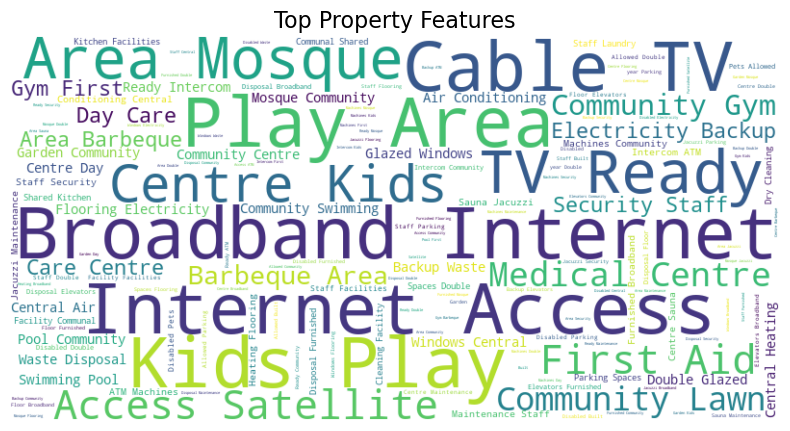

In [63]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

clean_features = []

for row in df['Features'].dropna():
    parts = str(row).split('|')

    for p in parts:
        p = p.strip()

        # ❌ remove unwanted patterns
        if ':' in p:   # removes Built in year, Parking Spaces, Floor etc.
            continue
        
        if 'nearby' in p.lower():
            continue
        
        
        if 'distance' in p.lower():
            continue
        
        if 'building' in p.lower():
            continue
        
        if 'other' in p.lower():
            continue

        # ✅ keep only meaningful features
        clean_features.append(p)

# 👉 final text for wordcloud
clean_text = " ".join(clean_features)
# WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',   
    colormap='viridis', 
).generate(clean_text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Top Property Features", fontsize=16)
plt.show()

In [64]:
import pickle

# save
with open('clean_text.pkl', 'wb') as f:
    pickle.dump(clean_text, f)

In [44]:
df['Features'].iloc[0]

'Built in year : 2026 | Parking Spaces : 2 | Lobby in Building | Double Glazed Windows | Central Air Conditioning | Central Heating | Flooring | Electricity Backup | Waste Disposal | Floor : 3 | Floors in Building : 9 | Elevators : 3 | Service Elevators in Building | Broadband Internet Access | Satellite or Cable TV Ready | Community Lawn or Garden | Community Gym | First Aid or Medical Centre | Day Care Centre | Kids Play Area | Barbeque Area | Mosque | Community Centre | Nearby Schools | Nearby Hospitals | Nearby Shopping Malls | Nearby Restaurants | Distance From Airport (kms) | Nearby Public Transport Service | Other Nearby Places | Maintenance Staff | Security Staff | Other Facilities'

In [ ]:
df['Features']

Index(['Property ID', 'Society', 'Society Link', 'Name', 'Page Title', 'Price',
       'Area', 'Bedrooms', 'Baths', 'Floor Number', 'Total Floors',
       'Built Year', 'Address', 'Description', 'Features',
       'Nearby Locations and Other Facilities', 'Rooms', 'Other Rooms', 'Link',
       'Built in year', 'Parking Spaces', 'Lobby in Building',
       'Double Glazed Windows', 'Central Air Conditioning', 'Central Heating',
       'Flooring', 'Electricity Backup', 'Waste Disposal', 'Floor',
       'Floors in Building', 'Elevators', 'Service Elevators in Building',
       'Broadband Internet Access', 'Satellite or Cable TV Ready',
       'Community Lawn or Garden', 'Community Gym',
       'First Aid or Medical Centre', 'Day Care Centre', 'Kids Play Area',
       'Barbeque Area', 'Mosque', 'Community Centre', 'Nearby Schools',
       'Nearby Hospitals', 'Nearby Shopping Malls', 'Nearby Restaurants',
       'Distance From Airport (kms)', 'Nearby Public Transport Service',
       'Other N